In [1]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/shwetabh123/mall-customers/Mall_Customers.csv")

In [2]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.shape

(200, 5)

In [6]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [7]:
X = df[[
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

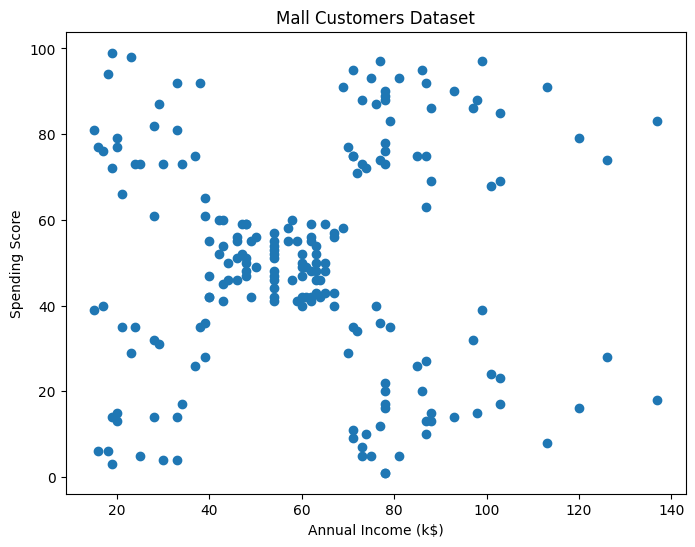

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"]
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Mall Customers Dataset")

plt.show()

In [9]:
from sklearn.cluster import KMeans

inertias = []

for k in range(1,11):
    kmeans=KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )

    kmeans.fit(X)

    inertias.append(
        kmeans.inertia_
    )

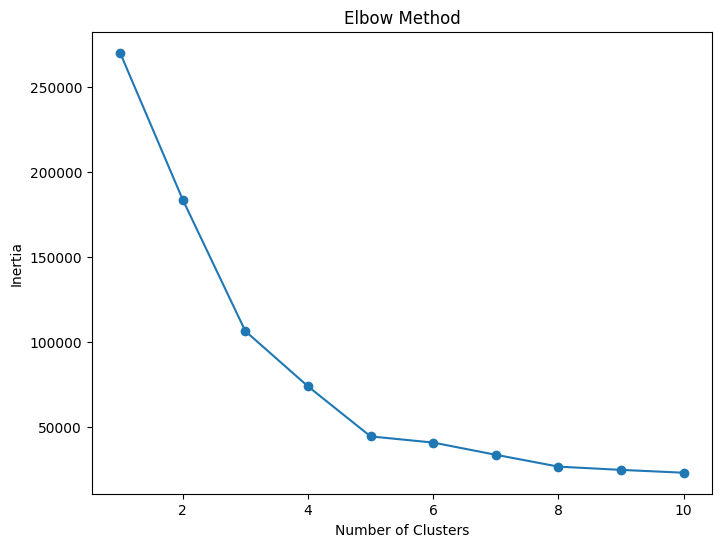

In [10]:
plt.figure(figsize=(8,6))

plt.plot(
    range(1,11),
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [11]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init="auto"
)

y_pred = kmeans.fit_predict(X)
df["Cluster"] = y_pred

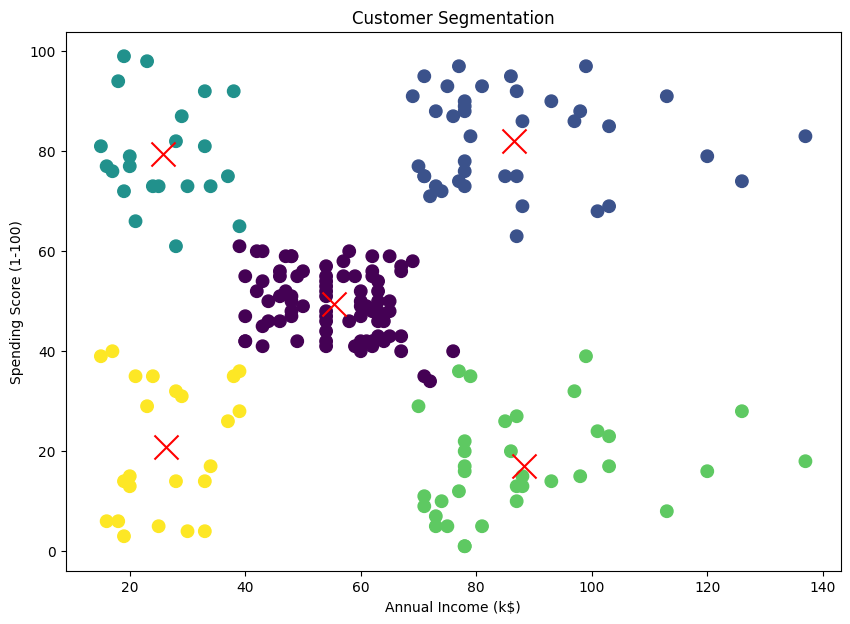

In [12]:
plt.figure(figsize=(10,7))

plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis",
    s=80
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    c="red",
    s=300,
    marker="x"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation")

plt.show()

In [13]:
cluster_names = {
    0: "Premium Customers ",
    1: "Conservative Wealthy ",
    2: "Standard Customers ",
    3: "Young Spenders ",
    4: "Budget Customers "
}

df["Segment"] = df["Cluster"].map(cluster_names)

In [14]:
import plotly.express as px

fig = px.scatter(
    df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    color="Segment",
    hover_data=["Age", "Genre"],
    size_max=20,
    title="Customer Segmentation Studio"
)

fig.update_layout(
    template="plotly_dark",
    width=1000,
    height=700
)

fig.show()

In [15]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Gender"] = encoder.fit_transform(df["Genre"])

In [16]:
X = df[[
    "Gender",
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [18]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init="auto"
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

In [19]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(X_scaled)

In [20]:
df["PCA1"] = X_pca[:,0]
df["PCA2"] = X_pca[:,1]

In [21]:
fig = px.scatter(
    df,
    x="PCA1",
    y="PCA2",
    color="Segment",
    hover_data=[
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ],
    title="Customer Segments (PCA Projection)"
)

fig.update_layout(
    template="plotly_dark",
    width=1000,
    height=700
)

fig.show()

In [22]:
cluster_summary = df.groupby("Segment").agg({
    "Age":"mean",
    "Annual Income (k$)":"mean",
    "Spending Score (1-100)":"mean"
}).round(1)

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Segment,,,
Budget Customers,45.2,26.3,20.9
Conservative Wealthy,32.7,86.5,82.1
Premium Customers,42.7,55.3,49.5
Standard Customers,25.3,25.7,79.4
Young Spenders,41.1,88.2,17.1


In [23]:
for segment in cluster_summary.index:
    age = cluster_summary.loc[segment, "Age"]
    income = cluster_summary.loc[segment, "Annual Income (k$)"]
    spending = cluster_summary.loc[segment, "Spending Score (1-100)"]
    
    print("\n" + "="*50)
    print(segment)

    print(f"Average Age:{age}")
    print(f"Average Annual Income:${income}k")
    print(f"Average Spending Score:{spending}")

    if income > 70 and spending>70:
        print("Insight: Premium high-value customers.")
        print("Strategy: Loyalty programs and VIP services.")

    elif income > 70 and spending < 40:
        print("Insight: Wealthy but low-spending customers.")
        print("Strategy: Targeted promotions and upselling.")

    elif income < 40 and spending > 60:
        print("Insight: Young impulsive spenders.")
        print("Strategy: Social media campaigns and discounts.")

    elif income < 40 and spending < 40:
        print("Insight: Budget-conscious customers.")
        print("Strategy: Value packs and price-sensitive offers.")

    else:
        print("Insight: Average customers.")
        print("Strategy: General retention campaigns.")


Budget Customers 
Average Age:45.2
Average Annual Income:$26.3k
Average Spending Score:20.9
Insight: Budget-conscious customers.
Strategy: Value packs and price-sensitive offers.

Conservative Wealthy 
Average Age:32.7
Average Annual Income:$86.5k
Average Spending Score:82.1
Insight: Premium high-value customers.
Strategy: Loyalty programs and VIP services.

Premium Customers 
Average Age:42.7
Average Annual Income:$55.3k
Average Spending Score:49.5
Insight: Average customers.
Strategy: General retention campaigns.

Standard Customers 
Average Age:25.3
Average Annual Income:$25.7k
Average Spending Score:79.4
Insight: Young impulsive spenders.
Strategy: Social media campaigns and discounts.

Young Spenders 
Average Age:41.1
Average Annual Income:$88.2k
Average Spending Score:17.1
Insight: Wealthy but low-spending customers.
Strategy: Targeted promotions and upselling.


In [24]:
df.to_csv(
    "customer_segments.csv",
    index=False
)